# <p align = "center"> Clustering Analysis of RMSD </p>

<details open>
<summary> <strong> <ins> Key Points </ins> </strong> </summary>

- Labels-aware

    - Ligand Labels

        - Visual Identification

- Labels-agnostic

</details>


In [ ]:
# Load Key Libraries
from pathlib import Path
rootdir = Path("../../../..").resolve()
import sys
sys.path.insert(0, str(rootdir) )
from typing import Callable, Generator

import gemmi 
import parasail
import numpy as np
from rdkit import Chem
import matplotlib.pyplot as plt

from xaidar.data.molecModels import loadPDB
from xaidar.data.molecModels import get_pdb_stats, sele_pdb, sele_Lig, get_res_CoM
from xaidar.data.molecModels import flatten_pdb, sele_AA, createPDB, get_atom_coord

/home/eoo22534/mydir/xaidar/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load rmsd matrix

In [2]:
saveDir = rootdir.joinpath("data/ev2a/fragalysis/03-calcs/ca_rmsd.npy")
ca_rmsd_matrix = np.load( saveDir )
print( "ca_rmsd_matrix shape: ",ca_rmsd_matrix.shape )

import pickle as pkl

with open( rootdir.joinpath("data/ev2a/fragalysis/03-calcs/ca_rmsd_id2set_map.pkl"), "rb" ) as file:
    ca_rmsd_id2set_map = pkl.load( file )
    _, lst_matrix_datasets = zip( *ca_rmsd_id2set_map)
    del _
print("\nca_rmsd_id2set_map Content: ", "\n\t",
        ca_rmsd_id2set_map[:10]
)
print( "\nlst_all_datasets: ", "\n\t",
      lst_matrix_datasets[:10])

with open( rootdir.joinpath("data/ev2a/fragalysis/03-calcs/ca_rmsd_set2id_map.pkl"), "rb" ) as file:
    ca_rmsd_set2id_map = pkl.load( file )
print("\nca_rmsd_set2id_map Keys and Subkeys and values: ", "\n\t",
       ca_rmsd_set2id_map.keys(), "\n\t", 
       list(ca_rmsd_set2id_map["piperidine"].keys())[:10],"\n\t",  
       list(ca_rmsd_set2id_map["piperidine"].values())[:10]  )

ca_rmsd_matrix shape:  (467, 467)

ca_rmsd_id2set_map Content:  
	 [('fragscreen', 'A0451a'), ('fragscreen', 'A0365a'), ('fragscreen', 'A1255a'), ('fragscreen', 'A0310a'), ('fragscreen', 'A1180a'), ('fragscreen', 'A0514a'), ('fragscreen', 'A1148a'), ('fragscreen', 'A1169a'), ('fragscreen', 'A0884a'), ('fragscreen', 'A0526a')]

lst_all_datasets:  
	 ('A0451a', 'A0365a', 'A1255a', 'A0310a', 'A1180a', 'A0514a', 'A1148a', 'A1169a', 'A0884a', 'A0526a')

ca_rmsd_set2id_map Keys and Subkeys and values:  
	 dict_keys(['fragscreen', 'nonactivesite', 'piperidine']) 
	 ['A0926a', 'A3054a', 'A3186a', 'A3188a', 'A3189a', 'A3191a', 'A3193a', 'A3194a', 'A3207a', 'A3208a'] 
	 [120, 121, 122, 123, 124, 125, 126, 127, 128, 129]


## Perform Spectral Clustering

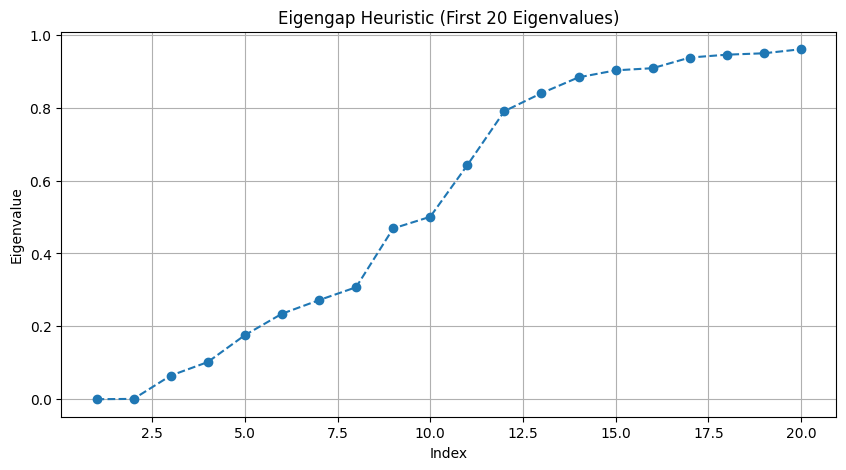

The suggested number of clusters is: 8


In [11]:
# Performing Clustering and Extracting the Matrix Index of Each Protein Associated to each Cluster Label -> spec_cluster_labels[ n_clusters][ clust_label (e.g. 0,1,...) ][ idxs | datasets | manual]
from sklearn.cluster import SpectralClustering
from collections import defaultdict
from scipy.sparse.csgraph import laplacian
from scipy.linalg import eigh
# spectral clustering on rmsd matrix

# 3. Convert Distance Matrix to an Affinity (Similarity) Matrix
# Spectral clustering needs high values for similar items, and low values for dissimilar items.
# We use a Gaussian (RBF) kernel conversion: exp(-gamma * distance^2)

# A common heuristic for gamma is 1 / variance of the distances
gamma = 1.0 / np.var(ca_rmsd_matrix)
affinity_matrix = np.exp(-gamma * ca_rmsd_matrix**2)

# Compute Normalized Laplacian in one line
# 'normed=True' computes L_sym = I - D^-1/2 A D^-1/2
L = laplacian(affinity_matrix, normed=True)

# 4. Solve for Eigenvalues
# Since L is symmetric, eigh is faster and more accurate than eig
eigenvalues, vecs = eigh(L)

# 5. Plot the Eigengap to identify the number of clusters
plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), eigenvalues[:20], marker='o', linestyle='--')
plt.title('Eigengap Heuristic (First 20 Eigenvalues)')
plt.xlabel('Index')
plt.ylabel('Eigenvalue')
plt.grid(True)
plt.show()

# The "Ideal K" is the index before the largest gap
gaps = np.diff(eigenvalues[:20])
k_ideal = np.argmax(gaps) + 1
print(f"The suggested number of clusters is: {k_ideal}")
n_clusters = k_ideal


In [4]:
clustering = SpectralClustering(n_clusters=k_ideal,                      # Perform Spectral Clustering
                        affinity='precomputed', assign_labels='kmeans')
clust_proj_labels = clustering.fit_predict( affinity_matrix )  

labels_dict = { }                                                           # Save cluster labels for each cluster project / campaign
for target_clst_label in set( clust_proj_labels):
    labels_dict[int(target_clst_label)] = {"idxs" : 
        [idx for idx,  clust_label in enumerate( clust_proj_labels )
        if int(clust_label) == int(target_clst_label) ] }                   # Add the indice of the proteins in the rmsd matrix that match each specific cluster label
    
ordered_labels_dict = dict( sorted(labels_dict.items(),                     # Order Based off of the size of the cluster
                key = lambda item: len(item[1]["idxs"]), reverse = True) )  
ordered_labels_dict = { idx : content                                       # Change Labels to Match the size order
            for idx, content in enumerate(ordered_labels_dict.values())}
clust_dict = ordered_labels_dict

In [5]:
# Link the Protein Dataset IDs to the Cluster Labels throught the matrix indices 
for clust_label, clust_label_dict in clust_dict.items():
        clust_label_dict["datasets"] = [ lst_matrix_datasets[idx] 
                                    for idx in clust_label_dict["idxs"] ]

### Load and add manual labels

In [6]:
manual_labels_path = rootdir.joinpath("data/ev2a/fragalysis/03-calcs/clustering/ligManualLabels.pkl")
with open(manual_labels_path, "rb") as file:
    manual_cluster_dict = pkl.load(  file)

In [7]:
# Create Unique ID Link Dictionary between dataset ID of rmsd matrix proteins and manual cluster labels
dataset2manual_Labels_dict = { dataset: label 
                        for label, list_datasets in manual_cluster_dict.items()
                        for dataset in list_datasets }

In [8]:
# Add Manual Labels to Unsupervised Spectral Clustering Labels 
for clust_id, clust_labels in clust_dict.items():
    clust_labels["manual_label"] = [ dataset2manual_Labels_dict[dataset]
                                for dataset in clust_labels["datasets"] ] 

In [9]:
# Matplotlib aiding function
def format_dual_axis(ax, sec_labels, cluster_labels ):
    # 1. Primary Ticks (Top)
    ax.xaxis.tick_top()
    top_ticks = list(range(0, 450, 100))
    ax.set_xticks(top_ticks)
    ax.set_xticklabels(top_ticks, rotation=90)

    # 2. Secondary Ticks (Bottom)
    # The lambda functions ensure the coordinates match the primary axis
    secax = ax.secondary_xaxis('bottom', functions=(lambda x: x, lambda x: x))
    
    bottom_ticks = sec_labels
    secax.set_xticks(bottom_ticks)
    secax.set_xticklabels(cluster_labels)
    
    # Access the underlying tick objects
    for i, tick in enumerate(secax.xaxis.get_major_ticks()):
        if i % 2 == 0:
            # Show label, hide tick line
            tick.tick1line.set_visible(False) 
            tick.label1.set_visible(True)
        else:
            # Hide label, show tick line
            tick.tick1line.set_visible(True)
            tick.label1.set_visible(False)
    return secax


Current Number of Clusters:  8
dict_keys([0, 1, 2, 3, 4, 5, 6, 7])
8
(8, 10)


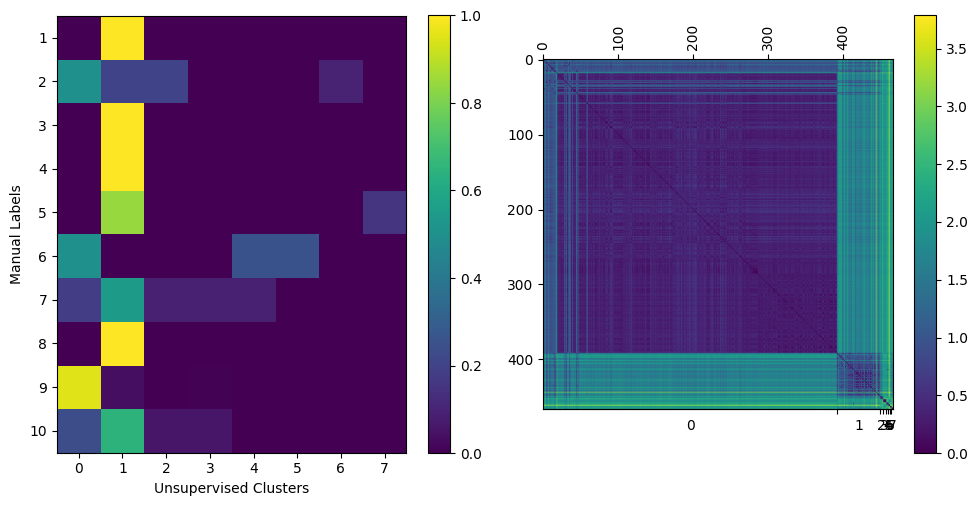

In [12]:
# Observe Manual Cluster VS Spectral Cluster Labels Interactively
 
print("Current Number of Clusters: ", n_clusters )
spec_clust_proj = clust_dict
print(spec_clust_proj.keys())
print(len(spec_clust_proj))
                                                                 # Make the Cell Interactive

size_ordered_spect_labels = list(spec_clust_proj.keys())
lst_manual_labels = [ [ spec_clust_proj[idx]["manual_label"].count(manual_label) 
                       / np.sum( np.array( [proj["manual_label"].count(manual_label) 
                        for proj in spec_clust_proj.values() ] ))
                      for manual_label in list( range( 1, 11 ) ) ]  
                    for idx in size_ordered_spect_labels ]

print( np.array(lst_manual_labels).shape)
labels_array = np.array(lst_manual_labels).T

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

im0 = ax[0].imshow(labels_array)
plt.colorbar(im0, ax=ax[0])
ax[0].set_ylabel("Manual Labels")
ax[0].set_xlabel("Unsupervised Clusters")
ax[0].set_xticks(list(range(len(spec_clust_proj))), labels = size_ordered_spect_labels)
ax[0].set_yticks(list(range(len(manual_cluster_dict.keys()))), labels=list(manual_cluster_dict.keys()))

new_order = [idx for clust in spec_clust_proj.values() for idx in clust["idxs"]]

new_coord_x, new_coord_y = list(zip(*[(x, y) for x in new_order for y in new_order]))
new_coord_x, new_coord_y = np.array(new_coord_x), np.array(new_coord_y)
reorder_rmsd_mat = ca_rmsd_matrix[new_coord_x, new_coord_y].reshape(ca_rmsd_matrix.shape[0], ca_rmsd_matrix.shape[0])

im1 = ax[1].imshow(reorder_rmsd_mat)
cumul_count = list(np.cumsum([len(clust["idxs"]) for clust in list(spec_clust_proj.values())]) )# list()
cumul_count = [np.float64(0)] + cumul_count
inbetween_vals = [ np.mean( [cumul_count[idx], cumul_count[idx+1]])   for idx in range(len(cumul_count)-1)]
all_ticks = [  item for list in  [ [btween, cumul] for btween, cumul in zip(inbetween_vals, cumul_count[1:] ) ] for item in list ]
all_labels = [  item for list in  [ [label, cumul] for label, cumul in zip(size_ordered_spect_labels, cumul_count[1:] ) ] for item in list ]
format_dual_axis(ax[1], all_ticks, all_labels)
plt.colorbar(im1, ax=ax[1])

plt.tight_layout()
plt.show()

### Extract Dataset names For a specific cluster name

In [13]:
print( [ item for item in clust_dict[0]["datasets"] ])

['A0365a', 'A0310a', 'A0514a', 'A1169a', 'A0884a', 'A0351a', 'A0387a', 'A0875a', 'A0528a', 'A0487a', 'A0911a', 'A0237a', 'A0437a', 'A0926a', 'A0207a', 'A0450a', 'A0554a', 'A1080a', 'A0812a', 'A7465a', 'A7501b', 'A3550b', 'A3181b', 'A7510b', 'A5836a', 'A6838a', 'A7491a', 'A5381a', 'A0528b', 'A7459a', 'A1105a', 'A0863a', 'A7014a', 'A5721b', 'A0875b', 'A0351b', 'A0379a', 'A7038a', 'A7475a', 'A0514b', 'A7515a', 'A7533a', 'A3977b', 'A7461a', 'A0554b', 'A0926a', 'A3054a', 'A3186a', 'A3188a', 'A3189a', 'A3191a', 'A3193a', 'A3194a', 'A3207a', 'A3208a', 'A3210a', 'A3218a', 'A3221a', 'A3222a', 'A3223a', 'A3225a', 'A3229a', 'A3417a', 'A3450a', 'A3480a', 'A3483a', 'A3485a', 'A3488a', 'A3489a', 'A3510a', 'A3546a', 'A3548a', 'A3550a', 'A3575a', 'A3581a', 'A3585a', 'A3587a', 'A3606a', 'A3612a', 'A3618a', 'A3665a', 'A3849a', 'A3868a', 'A3883a', 'A3890a', 'A3901a', 'A3908a', 'A3914a', 'A3920a', 'A3936a', 'A3937a', 'A3938a', 'A3939a', 'A3940a', 'A3942a', 'A3944a', 'A3954a', 'A3968a', 'A3975a', 'A3982a',